# Chapter-09. Pytorch常用损失函数

## 【章节目标】
- 理解损失函数在模型训练中的作用
- 掌握分类任务损失函数及其使用方法
- 掌握回归任务损失函数及其使用方法
- 掌握自定义损失函数的方法
- 掌握不平衡学习损失函数Focal Loss和GHM Loss原理及实现方法

## 【章节内容】
### 9.1 损失函数的作用
#### 1）回顾机器学习训练步骤

首先回顾一下机器学习模型训练步骤：  
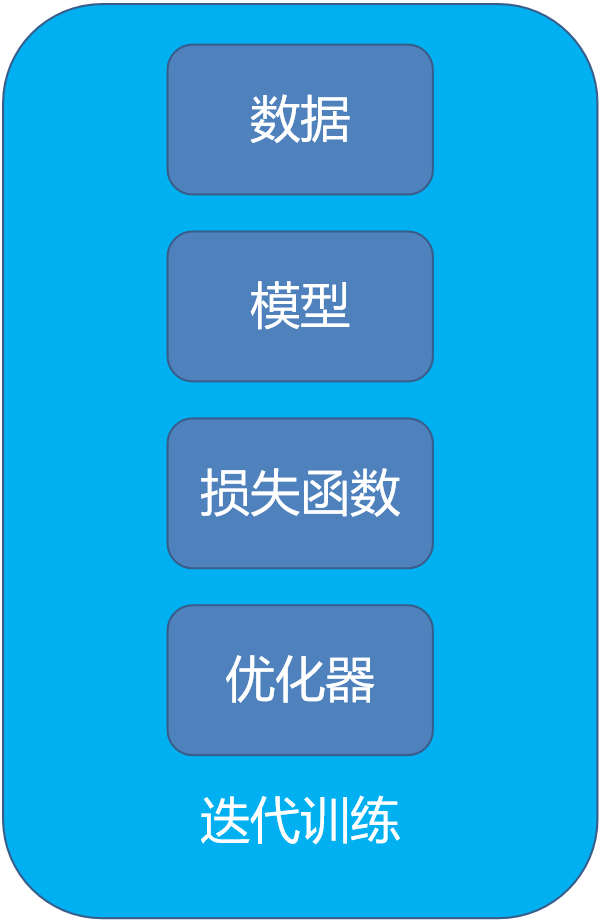  
对照代码观察：  
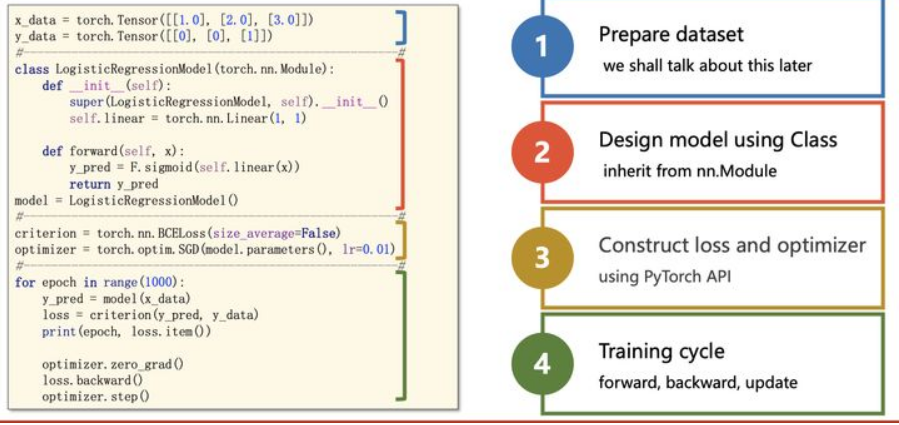

#### 2）损失函数和目标函数
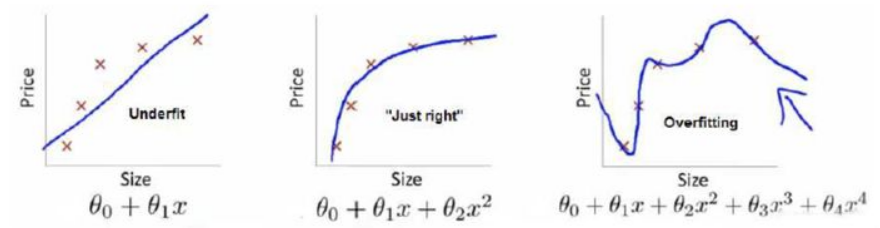  
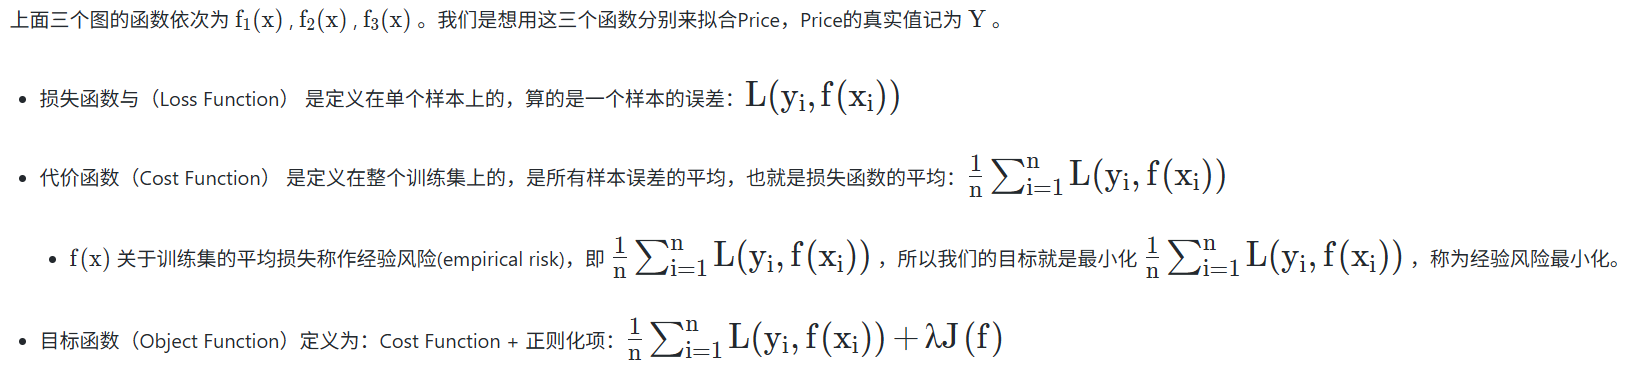

#### 3）pytorch的损失函数使用方法
pytorch中的损失函数有两种形式：（损失函数层本身也是一个计算层，也是继承于nn.Module）

- 类：位于torcn.nn模块下，使用方法为:
    - criterion = LossCriterion() #首先实例化损失函数对象
    - loss = criterion(y_pred, target) #调用损失函数对象并传入预测值和真实值
- 函数：位于torch.nn.functional模块下，使用方法为：
    - F.loss(y_pred, target)

回顾手写数字识别的代码：

In [ ]:
network = Net()#实例化网络模型
loss_func=torch.nn.NLLLoss()#实例化损失函数对象
optimizer = optim.Adam(network.parameters(), lr=learning_rate)

network.initialize_normal()
network.train()
for epoch in  range(n_epochs):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = network(data)
        loss = loss_func(output, target)#调用损失函数对象计算损失值
        loss.backward()#反向传播求导
        optimizer.step()#更新参数
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

### 9.2 分类任务损失函数
#### 1）NLLLoss

torch.nn.NLLLoss(weight=None, ignore_index=-100, reduction='mean')  
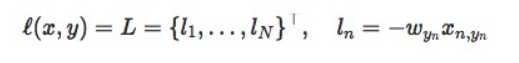  
功能：实现负对数似然函数中的负号功能， 用于训练 C 个类别的分类问题. 主要参数：

- weight：各类别的loss设置权值
- ignore_index：忽略某个类别
- reduction ：计算模式，可为none/sum/mean
    - none-逐个元素计算
    - sum-所有元素求和，返回标量
    - mean-加权平均，返回标量
- 它先通过logSoftmax()，然后把label对应的输出值拿出来，负号去掉，然后平均。
- 注意: logSoftmax() = log(softmax())
- output维度: (batch_size, class_num) # FloatTensor
- target维度: (batch_size) # LongTensor

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
input = torch.randn(5, 3) # 模拟网络的输出，这里是softmax层的输入
print("input: ", input)
label = torch.LongTensor([0, 2, 1, 1, 2]) # 真实label，这里不用onehot，onehot本质也是用真实label去索引
output = F.log_softmax(input, dim = 1) # 先softmax计算出概率，然后计算概率的对数
print("output: ", output)
loss_func = nn.NLLLoss()
loss = loss_func(output, label)
print("loss: ", loss)

input:  tensor([[-1.8919,  0.6841, -0.5945],
        [ 1.1117,  0.1445,  0.1463],
        [ 0.0414,  1.0218,  0.3359],
        [-2.0802,  1.5872,  2.0216],
        [ 1.7244, -2.4078,  1.2337]])
output:  tensor([[-2.8794, -0.3034, -1.5820],
        [-0.5659, -1.5331, -1.5313],
        [-1.6110, -0.6306, -1.3165],
        [-4.6112, -0.9438, -0.5093],
        [-0.4875, -4.6196, -0.9782]])
loss:  tensor(1.3927)


In [2]:
input = torch.FloatTensor(
    [[-1.8919,  0.6841, -0.5945],
    [ 1.1117,  0.1445,  0.1463],
    [ 0.0414,  1.0218,  0.3359],
    [-2.0802,  1.5872,  2.0216],
    [ 1.7244, -2.4078,  1.2337]]
)

# 1. softmax + log = torch.log_softmax()
sm = nn.Softmax(dim = 1)
output = torch.log(sm(input))
print(output)

# 2. 就是取对数的负值成对应的label  也就是交叉熵
-output[[0, 1, 2, 3, 4], [0, 2, 1, 1, 2]].mean()

tensor([[-2.8794, -0.3034, -1.5820],
        [-0.5659, -1.5331, -1.5313],
        [-1.6110, -0.6306, -1.3165],
        [-4.6111, -0.9437, -0.5093],
        [-0.4875, -4.6197, -0.9782]])


tensor(1.3927)

#### 2）CrossEntropyLoss

torch.nn.CrossEntropyLoss(weight=None, ignore_index=-100, reduction='mean')

- 交叉熵，实际上它是由nn.LogSoftmax()和nn.NLLLoss()组成。 主要应用在多分类的问题中(二分类也可以用)
- 当训练有 C 个类别的分类问题时很有效. 可选参数 weight 必须是一个1维 Tensor, 权重将被分配给各个类别. 对于不平衡的训练集非常有效。
- 在多分类任务中，经常采用 softmax 激活函数+交叉熵损失函数，因为交叉熵描述了两个概率分布的差异，然而神经网络输出的是向量，并不是概率分布的形式。所以需要 softmax激活函数将一个向量进行“归一化”成概率分布的形式，再采用交叉熵损失函数计算 loss。  
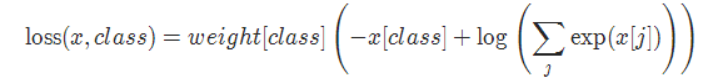  
- output维度: (batch_size, class_num) # FloatTensor
- target维度: (batch_size,) # LongTensor

In [3]:
loss_func1 = nn.CrossEntropyLoss()
output = torch.FloatTensor(
    [[-1.8919,  0.6841, -0.5945],
    [ 1.1117,  0.1445,  0.1463],
    [ 0.0414,  1.0218,  0.3359],
    [-2.0802,  1.5872,  2.0216],
    [ 1.7244, -2.4078,  1.2337]]
)

true_label = torch.LongTensor([0, 2, 1, 1, 2])  # 注意这里的label id必须从0开始 不能说label id是1，2，3 必须是0，1，2
loss = loss_func1(output, true_label)
print(loss)

tensor(1.3927)


#### 3）BCELoss

torch.nn.BCELoss(weight=None, reduction='mean')
- BCE Loss就是二分类的交叉熵(它才是严格按照交叉熵的公式去算的，但只针对二分类) BCEloss一般应用在单标签二分类和多标签二分类中。
- BCELoss的公式:  
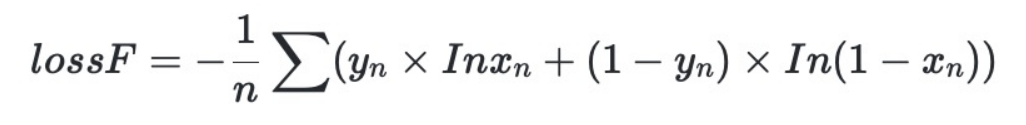  
- 对于单标签二分类：
    - 模型output的tensor维度为:(batch_size, 1) # torch.FloatTensor
    - target的维度:(batch_size, 1)
- 对于多标签二分类：
    - 模型output的tensor维度为(batch_size, label_num) # torch.FloatTensor
    - target的维度: (batch_size, label_num) 不是onehot
    
**注意：模型output必须要经过sigmoid函数运算**

二分类的问题代码验证：

In [4]:
bce = nn.BCELoss()
x = torch.FloatTensor([
    [0.0550], # 每个样本只输出一个概率值
    [0.7060]
])
s = nn.Sigmoid()
output = s(x)
# 假设是一条数据为2分类
label = torch.FloatTensor(
    [
        [1],
        [0]
    ]
)
loss = bce(output, label)
print(loss)

tensor(0.8866)


In [6]:
x = torch.FloatTensor(
    [
        [ 0.0550],
        [ 0.7060]
    ]
)
# 注意  输出要经过sigmoid
s = nn.Sigmoid()
output = s(x)
# print(output)
# tensor([[0.5137],
#         [0.6695]])
# true_label = [[1], [0]]
score1= 1 * torch.log(torch.tensor(0.5137)) + (1 - 1) * torch.log(torch.tensor(1 - 0.5137))

score2= 0 * torch.log(torch.tensor(0.6695)) + (1 - 0) * torch.log(torch.tensor(1 - 0.6695))
print(-(score1 + score2) / 2)  # 输出0.6327

tensor(0.8866)


多标签分类代码验证：

In [2]:
import torch 
from torch import nn
bce = nn.BCELoss()
x = torch.FloatTensor(
    [
        [ 0.0550, -0.5005, -0.4188],#每个样本输出3个概率值，意味着有三个标签
        [ 0.7060,  1.1139, -0.0016],#使用sigmoid统一样本之间的概率值不竞争，softmax反之
        [ 0.3008, -0.9968,  0.5147]
    ]
)
# 注意  输出要经过sigmoid
s = nn.Sigmoid()
output = s(x)
# 假设是一条数据多个标签的分类
label = torch.FloatTensor(
    [
        [1, 0, 1],#不是onehot向量
        [0, 0, 1],
        [1, 1, 0]
    ]
)
loss = bce(output, label)
print(loss)

tensor(0.9013)


In [4]:
# 1. 模型输出
output = torch.FloatTensor(
    [
        [ 0.0550, -0.5005, -0.4188],
        [ 0.7060,  1.1139, -0.0016],
        [ 0.3008, -0.9968,  0.5147]
    ]
)
# 2. 经过sigmoid
s = nn.Sigmoid()
output = s(output)
# print(output)
# tensor([[0.5137, 0.3774, 0.3968],
#         [0.6695, 0.7529, 0.4996],
#         [0.5746, 0.2696, 0.6259]])
label = torch.FloatTensor(
    [
        [1, 0, 1],
        [0, 0, 1],
        [1, 1, 0]
    ]
)
# 根据标签和sigmoid计算出计算
# 第一行
sum_1 = 0
sum_1 += 1 * torch.log(torch.tensor(0.5137)) + (1 - 1) * torch.log(torch.tensor(1 - 0.5137))   # 第一个标签的二分类损失
sum_1 += 0 * torch.log(torch.tensor(0.3774)) + (1 - 0) * torch.log(torch.tensor(1 - 0.3774))   # 第二个标签的二分类损失
sum_1 += 1 * torch.log(torch.tensor(0.3968)) + (1 - 1) * torch.log(torch.tensor(1 - 0.3968))   # 第三个标签的二分类损失
avg_1 = sum_1 / 3
# 第二行
sum_2 = 0
sum_2 += 0 * torch.log(torch.tensor(0.6695)) + (1 - 0) * torch.log(torch.tensor(1 - 0.6695))   # 第一列
sum_2 += 0 * torch.log(torch.tensor(0.7529)) + (1 - 0) * torch.log(torch.tensor(1 - 0.7529))   # 第二列
sum_2 += 1 * torch.log(torch.tensor(0.4996)) + (1 - 1) * torch.log(torch.tensor(1 - 0.4996))   # 第三列
avg_2 = sum_2 / 3
# 第三行
sum_3 = 0
sum_3 += 1 * torch.log(torch.tensor(0.5746)) + (1 - 1) * torch.log(torch.tensor(1 - 0.5746))   # 第一列
sum_3 += 1 * torch.log(torch.tensor(0.2696)) + (1 - 1) * torch.log(torch.tensor(1 - 0.2696))   # 第二列
sum_3 += 0 * torch.log(torch.tensor(0.6259)) + (1 - 0) * torch.log(torch.tensor(1 - 0.6259))   # 第三列
avg_3 = sum_3 / 3

result = -(avg_1 + avg_2 + avg_3) / 3
print(result)   # 输出0.9013

tensor(0.9013)


#### 4）BCEWithLogitsLoss

torch.nn.BCEWithLogitsLoss(weight=None, reduction='mean', pos_weight=None)  
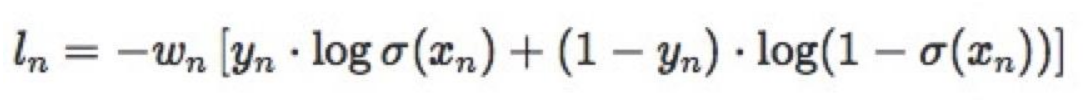  
- BCEWithLogitsLoss损失函数把 Sigmoid 层集成到了 BCELoss 类中. 该版比用一个简单的 Sigmoid 层和 BCELoss 在数值上更稳定, 因为把这两个操作合并为一个层之后, 可以利用 log-sum-exp 的 技巧来实现数值稳定.
- pos_weight(Tensor, optional) – 自定义的每个正样本的 loss 的权重. 必须是一个长度 为 “classes” 的 Tensor

In [5]:
bce_logit = nn.BCEWithLogitsLoss()
output = torch.FloatTensor(
    [
        [ 0.0550],
        [ 0.7060]
    ]
)   # 未经Sigmoid
label = torch.FloatTensor(
    [
        [1],
        [0]
    ]
)
loss = bce_logit(output, label)
print(loss)

tensor(0.8866)


In [6]:
bce_logit = nn.BCEWithLogitsLoss()
x = torch.FloatTensor(
    [
        [ 0.0550, -0.5005, -0.4188],#每个样本输出3个概率值，意味着有三个标签
        [ 0.7060,  1.1139, -0.0016],
        [ 0.3008, -0.9968,  0.5147]
    ]
)
# 假设是一条数据多个标签的分类
label = torch.FloatTensor(
    [
        [1, 0, 1],#不是onehot向量
        [0, 0, 1],
        [1, 1, 0]
    ]
)
loss = bce_logit(x, label)
print(loss)   # 输出: 0.9013

tensor(0.9013)


#### 5）MultiMarginLoss

torch.nn.MultiMarginLoss(p=1, margin=1.0, weight=None, reduction='mean')  
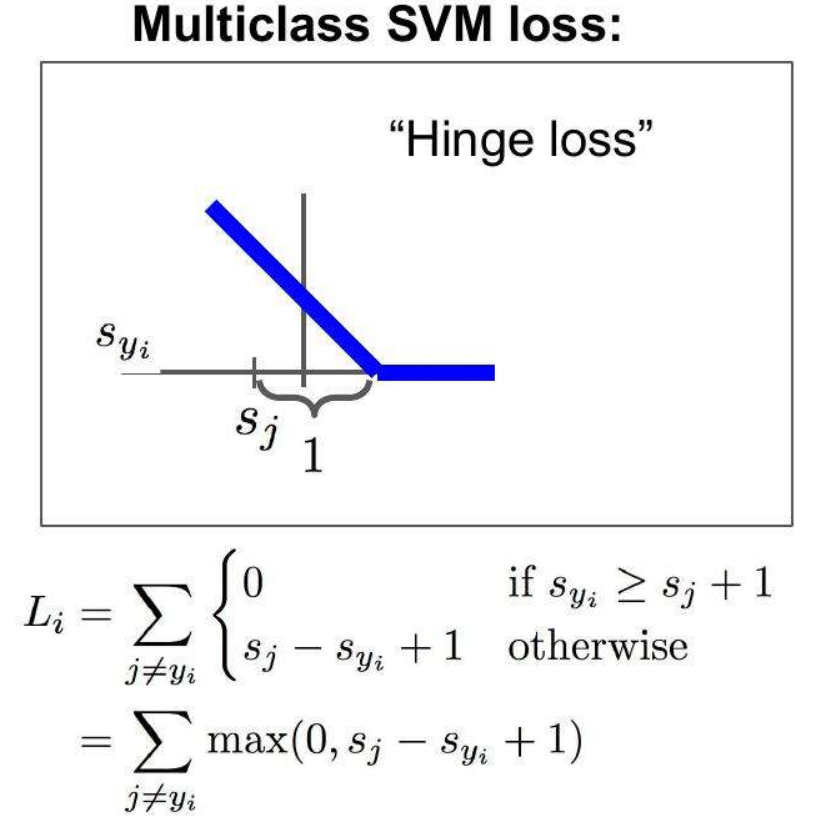  
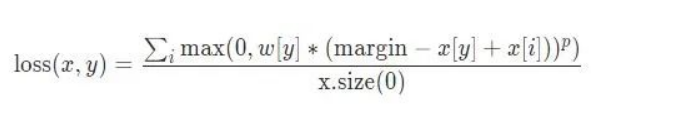  
- weight为根据样本类别分布而设置的权重，可选择性设置。
- margin为hinge的阈值，就像图像表示的函数，1也是margin值。
- x[i]为该样本错误预测的得分，x[y]为正确预测的得分。两者的差值可用来表示两种预测结果的相似关系，margin是一个由自己指定的安全系数。
- 我们希望正确预测的得分高于错误预测的得分，且高出一个边界值 margin，换句话说，x[y]越高越好，x[i]越低越好，(x[i] - x[y])越小越好，但二者得分之差最多为margin就足够了，差距更大并不会有任何奖励。这样设计的目的在于，对单个样本正确分类只要有margin的把握就足够了，更大的把握则不必要，过分注重单个样本的分类效果反而有可能使整体的分类效果变坏。分类器应该更加专注于整体的分类误差。

In [3]:
import torch
from torch import nn
import torch.nn.functional as F

x = torch.FloatTensor([[0.1, 0.2, 0.4, 0.8], [0.1, 0.2, 0.4, 0.8]]) # 注意：四个概率和不为1
print(x.size())
y = torch.LongTensor([3, 3])
print(y.size())

loss = nn.MultiMarginLoss(reduction = 'none')
loss_val = loss(x, y)
print(loss_val)

loss = nn.MultiMarginLoss(reduction = 'sum')
loss_val = loss(x, y)
print(loss_val)
print(loss_val.item())
print(loss_val.item() / x.size(0))
#验证
print(1 / 2 * 1 / 4 * ((1 - 0.8 + 0.1) + (1 - 0.8 + 0.2) + (1 - 0.8 + 0.4) +
                       (1 - 0.8 + 0.1) + (1 - 0.8 + 0.2) + (1 - 0.8 + 0.4)))

torch.Size([2, 4])
torch.Size([2])
tensor([0.3250, 0.3250])
tensor(0.6500)
0.6499999761581421
0.32499998807907104
0.32499999999999996


#### 6）MultiLabelMarginLoss

torch.nn.MultiLabelMarginLoss(reduction='mean')

- 多标签合页损失（hinge loss），上述的多分类合页损失MultiMarginLoss应用于一个样本的仅仅对应一个真实标签的情况。

- 而MultiLabelMarginLoss应用于一个样本对应多个真实标签的情况，但是标签总数不超过C  
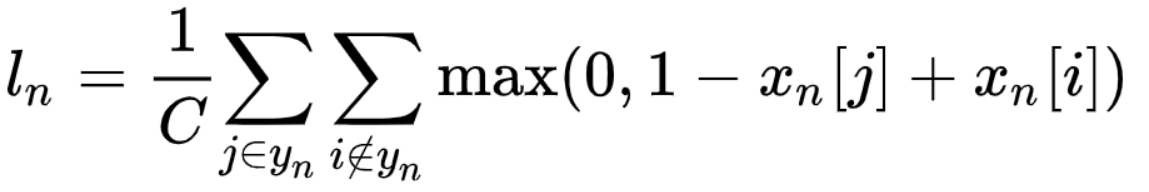  
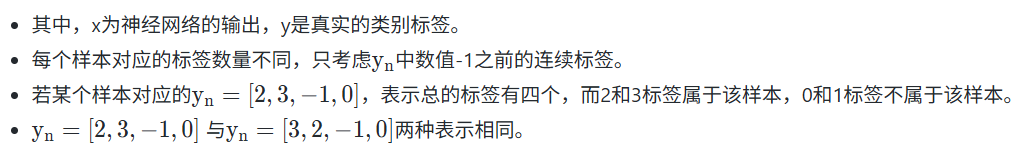

In [5]:
loss = nn.MultiLabelMarginLoss()
x = torch.FloatTensor([[0.1, 0.2, 0.4, 0.8]])
y = torch.LongTensor([[3, 0, -1, 1]])
print(x.size())
print(y.size())

loss_val = loss(x, y)
print(loss_val.item())
# 验证
print(0.25 * ((1 - (0.8 - 0.2)) + (1 - (0.8 - 0.4)) + (1 - (0.1 - 0.2)) + (1 - (0.1 - 0.4))))

y = torch.LongTensor([[3, 0, 1, -1]])
loss_val = loss(x, y)
print(loss_val.item())
# 验证
print(0.25 * ((1 - (0.8 - 0.4)) + (1 - (0.1 - 0.4)) + (1 - (0.2 - 0.4))))

y = torch.LongTensor([[3, 0, 2, 1]])
loss_val = loss(x, y)
print(loss_val.item())
# 如果包含全部的标签，loss为0?

torch.Size([1, 4])
torch.Size([1, 4])
0.8500000238418579
0.8500000000000001
0.7749999761581421
0.7749999999999999
0.0


#### 7）SoftMarginLoss

torch.nn.SoftMarginLoss(reduction='mean')  

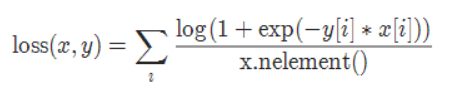

该损失函数功能等价于BCEWithLogitsLoss单标签二分类情况，区别在于target必须为{-1, 1}
- 模型output的tensor维度为:(batch_size, 1) # torch.FloatTensor
- target的维度:(batch_size, 1)

In [6]:
bce_logit = nn.SoftMarginLoss()
output = torch.FloatTensor(
    [
        [ 0.0550],
        [ 0.7060]
    ]
)   # 未经Sigmoid
label = torch.FloatTensor(
    [
        [1],
        [-1]
    ]
)
loss = bce_logit(output, label)
print(loss)   # tensor(0.8866)

tensor(0.8866)


#### 8）MultiLabelSoftMarginLoss

torch.nn.MultiLabelSoftMarginLoss(weight=None, reduction='mean')  
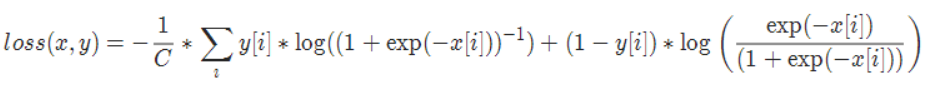  
多标签 one-versus-all 损失，相当于使用sigmoid+交叉熵的形式来解决多分类问题，功能等价于BCEWithLogitsLoss多标签多分类的情况。
- 模型output的tensor维度为(batch_size, label_num) # torch.FloatTensor
- target的维度: (batch_size, label_num) 不是onehot

In [7]:
bce = nn.MultiLabelSoftMarginLoss()
output = torch.FloatTensor(
    [
        [ 0.0550, -0.5005, -0.4188],
        [ 0.7060,  1.1139, -0.0016],
        [ 0.3008, -0.9968,  0.5147]
    ]
)

# 假设是一条数据多个标签的分类
label = torch.FloatTensor(
    [
        [1, 0, 1],
        [0, 0, 1],
        [1, 1, 0]
    ]
)
loss = bce(output, label)
print(loss)   # 输出: 0.9013

tensor(0.9013)


### 9.3 回归任务损失
#### 1）L1Loss

torch.nn.L1Loss(reduction='mean')  
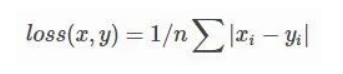  
计算 output 和 target 之差的绝对值。
- output维度: (batch_size, 1) # FloatTensor
- target维度: (batch_size, 1) # FloatTensor  

图中可以看出，权重W跟前后两层的神经元个数都相关！！！

In [8]:
input_data = torch.FloatTensor([[3], [4], [5]]) # batch_size, output
target_data = torch.FloatTensor([[2], [5], [8]]) # batch_size, output
loss_func = nn.L1Loss()
loss = loss_func(input_data, target_data)
print(loss)

tensor(1.6667)


In [9]:
print((abs(3-2) + abs(4-5) + abs(5-8)) / 3)

1.6666666666666667


#### 2）MSELoss(L2Loss)

torch.nn.MSELoss(reduction='mean')  
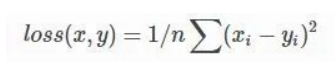  
计算 output 和 target 之差的均方差
- output维度: (batch_size, 1) # FloatTensor
- target维度: (batch_size, 1) # FloatTensor

In [11]:
input_data = torch.FloatTensor([[3], [4], [5]])   # batch_size, output
target_data = torch.FloatTensor([[2], [5], [8]])   # batch_size, output 
loss_func = nn.MSELoss()
loss = loss_func(input_data, target_data)
print(loss)   # 3.6667

tensor(3.6667)


In [12]:
print(((3-2)**2 + (4-5)**2 + (5-8)**2)/3)  # 3.6666666666666665

3.6666666666666665


#### 3）SmoothL1Loss

torch.nn.SmoothL1Loss(reduction='mean')

SmoothL1Loss是huber损失函数的特殊情况，Huber loss结合了MSE和MAE，定义如下：  
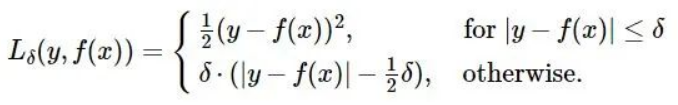  
- Huber Loss 包含了一个超参数 δ。δ 值的大小决定了 Huber Loss 对 MSE 和 MAE 的侧重性，当 |y−f(x)| ≤ δ 时，变为 MSE；当 |y−f(x)| > δ 时，则变成类似于 MAE
- 因此Huber Loss 同时具备了 MSE 和 MAE 的优点，减小了对离群点的敏感度问题，实现了处处可导的功能。
- Smooth L1 loss就是Huber loss的参数δ取值为1时的形式。在Faster R-CNN以及SSD中对边框的回归使用的损失函数都是Smooth L1 loss。

In [13]:
input_data = torch.FloatTensor([[3], [4], [5]])   # batch_size, output
target_data = torch.FloatTensor([[2], [4.1], [8]])   # batch_size, output 
loss_func = nn.SmoothL1Loss()
loss = loss_func(input_data, target_data)
print(loss)   # 输出:1.0017

tensor(1.0017)


### 9.4 特殊任务损失函数
#### 1）Triplet loss

torch.nn.TripletMarginLoss(margin=1.0, p=2.0, eps=1e-06, swap=False, reduction='mean')
- Triplet loss用于训练差异性较小的样本，最初出现在FaceNet的论文中：FaceNet: A Unified Embedding for Face Recognition and Clustering (https://arxiv.org/pdf/1503.03832.pdf)，可以学到较好的人脸的embedding。
- Triplet loss的输入是一个三元组：(anchor，positive， negative)，其中，从训练数据集中随机选一个样本，该样本称为anchor，然后随机选取和anchor同类的样本positive和不同类的样本negative。

下图是人脸embedding产生的Triplet loss：  
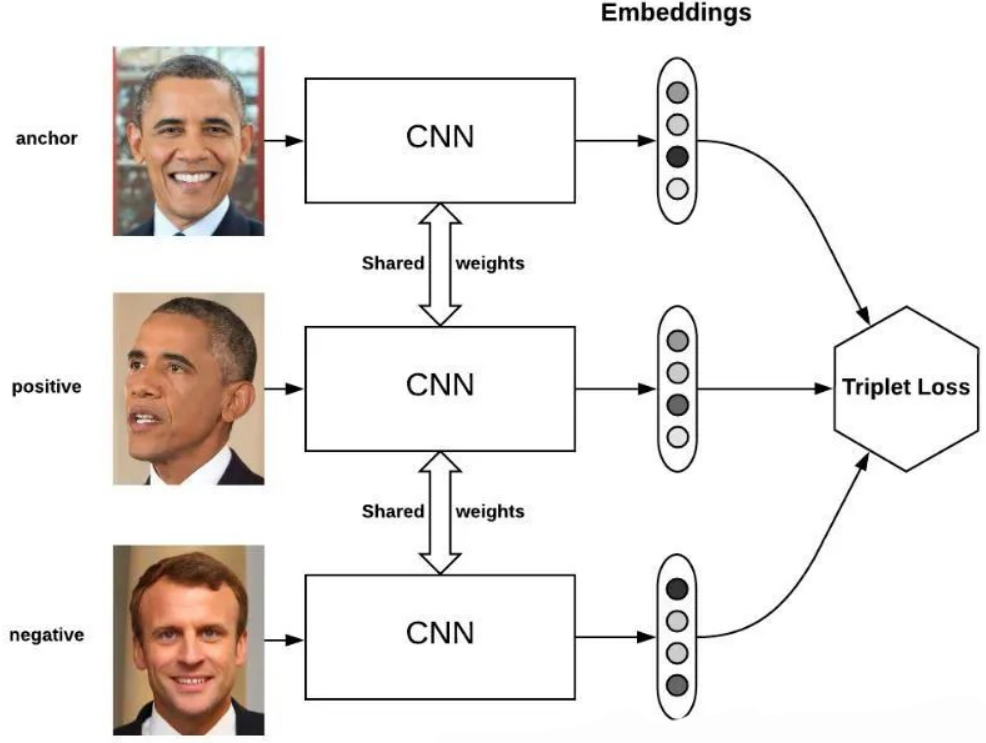  
Triplet loss的公式如下：  
$$
L(a, p, n) = \max \left( d(a, p) - d(a, n) + \text{margin}, \; 0 \right)
$$

$$
d(x, y) = \|x - y\|_p
$$

代码案例：

In [14]:
import numpy as np
triplet_loss = torch.nn.TripletMarginLoss(margin = 1.0, p = 2)
anchor = torch.randn(2, 5)
positive = torch.randn(2, 5)
negative = torch.randn(2, 5)

loss = triplet_loss(anchor, positive, negative)
print(loss)

dap = np.sqrt(np.square(anchor - positive).sum(axis = 1))
dan = np.sqrt(np.square(anchor - negative).sum(axis = 1))
d = dap - dan + 1
loss2 = np.where(d > 0, d, 0)
print(loss2)
print(loss2.mean())

tensor(0.7060)
[0.4407711 0.9712672]
0.70601916


#### 2）KL 散度损失 KLDivLoss

torch.nn.KLDivLoss(reduction='mean')  
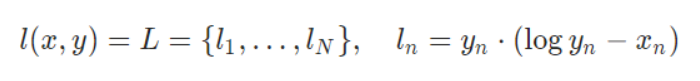  
计算 input 和 target 之间的 KL 散度。KL 散度可用于衡量不同的连续分布之间的距离, 并且对离散采用的连续输出空间分布进行回归通常很有用；用label_smoothing就采用这个；

In [ ]:
kl_loss = nn.KLDivLoss()
 
# 生成网络输出 以及 目标输出
output = torch.rand(2, 5)#必须是正数
target = torch.rand(2, 5)

loss_1 = kl_loss(output, target)

print('\nloss: ', loss_1)

# 熟悉计算公式，手动计算损失
loss_2 = target * (torch.log(target) - output)
print(loss_2)
print(loss_2.mean())


loss:  tensor(-0.4597)
tensor([[-0.2955, -0.0804, -0.4099, -0.2908, -0.4737],
        [-0.5672, -0.6833, -0.7779, -0.4869, -0.5311]])
tensor(-0.4597)


d:\anaconda3\envs\AI_Env\lib\site-packages\torch\nn\modules\loss.py:558: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  return F.kl_div(


#### 3）MarginRankingLoss

torch.nn.MarginRankingLoss(margin=0.0, reduction='mean')

用于排序任务。当两个量之间的距离大于 margin，则 loss 为正，小于margin，loss 为 0。

计算公式：
$$
L(x, y) = \max \left( 0,\; -y \cdot (x_1 - x_2) + \text{margin} \right)
$$
y == 1 时，x1 要比 x2 大，才不会有 loss，反之，y == -1 时，x1 要比 x2 小，才不会 有 loss。

注意：output是一对值，target必须为{-1，1}

In [16]:
mr_loss = nn.MarginRankingLoss()
 
# 生成网络输出 以及 目标输出
output1 = torch.randn(3)  #x1
output2 = torch.randn(3)  #x2
target=torch.tensor([-1,1,1]) #y

loss_1 = mr_loss(output1,output2, target)

print('\nloss: ', loss_1)

# 熟悉计算公式，手动计算损失
dst=-target*(output1-output2)+0
loss_2 = np.where(dst>0,dst,0)
print(loss_2)
print(loss_2.mean())


loss:  tensor(0.9794)
[2.2108855  0.7038197  0.02348316]
0.97939616


#### 4）HingeEmbeddingLoss

torch.nn.HingeEmbeddingLoss(margin=1.0, reduction='mean')

计算两个输入的相似性，常用于非线性embedding和半监督学习

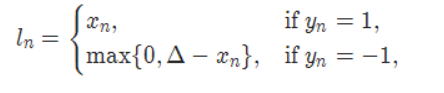

x代表两个向量的距离，y代表真实的标签，y中元素的值属于{ 1 , − 1 } ，分别表示相似与不相似。

In [17]:
hem_loss = nn.HingeEmbeddingLoss()
 
# 生成网络输出 以及 目标输出
output1 = torch.randn(2,5)
output2 = torch.randn(2,5)
target=torch.tensor([-1,1])

x=F.pairwise_distance(output1, output2, p=2)#计算向量距离
print(x)
loss_1 = hem_loss(x, target)

print('\nloss: ', loss_1)

# 熟悉计算公式，手动计算损失
loss_2 = np.where(target>0,x,np.where(1.0-x>0,1.0-x,0))
print(loss_2)
print(loss_2.mean())

tensor([3.8894, 3.5596])

loss:  tensor(1.7798)
[0.        3.5595953]
1.7797977


#### 5）CosineEmbeddingLoss

torch.nn.CosineEmbeddingLoss(margin=0.0, reduction='mean')

余弦相似度损失函数，用于判断输入的两个向量是否相似。 常用于非线性词向量学习以及半监督学习。  
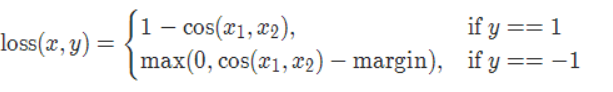  
x代表有一对向量x1, x2构成的输入样本, cos(x1, x2)代表两个向量x1, x2的夹角余弦值，y代表真实的类别标签，属于{1,−1}，分别表示相似与不相似。

In [18]:
cosine_loss  = nn.CosineEmbeddingLoss()
 
# 生成网络输出 以及 目标输出
output1 = torch.randn(2,5)
output2 = torch.randn(2,5)
target=torch.tensor([-1,1])

loss_1 = cosine_loss(output1,output2, target)

print('\nloss: ', loss_1)

# 熟悉计算公式，手动计算损失

margin=0
cosin=torch.cosine_similarity(output1,output2,dim=1)#计算余弦相似度
loss_2 = np.where(target>0,1-cosin,np.where(cosin-margin>0,cosin-margin,0))
print(loss_2)
print(loss_2.mean())


loss:  tensor(0.5657)
[0.5578509 0.5734633]
0.56565714


### 9.5 不平衡学习损失函数
#### 1）自定义损失函数

损失函数一般是网络中的最后一层，跟自定义Module一样需要继承nn.Module基类并实现init和forward方法。

**查看L1-Loss源码**

In [ ]:
class _Loss(Module):#继承nn.Module
    def __init__(self, size_average=None, reduce=None, reduction='mean'):
        super(_Loss, self).__init__()
        if size_average is not None or reduce is not None:
            self.reduction = _Reduction.legacy_get_string(size_average, reduce)
        else:
            self.reduction = reduction
            
class L1Loss(_Loss):#继承_Loss
    __constants__ = ['reduction']

    def __init__(self, size_average=None, reduce=None, reduction='mean'):
        super(L1Loss, self).__init__(size_average, reduce, reduction)

    def forward(self, input, target):
        return F.l1_loss(input, target, reduction=self.reduction)

In [21]:
class MSE(nn.Module):
    def __init__(self):
        super(MSE, self).__init__()
    
    def forward(self, input, target):
        return np.mean(np.sum(np.square(input - target).numpy(), axis=-1))
    
input_data = torch.FloatTensor([[3], [4], [5]])   # batch_size, output
target_data = torch.FloatTensor([[2], [5], [8]])   # batch_size, output 
loss_func1 = nn.MSELoss()
loss_func2 = MSE()
loss1 = loss_func1(input_data, target_data)
loss2 = loss_func2(input_data, target_data)
print(loss1,loss2)   # 3.6667

tensor(3.6667) 3.6666667


#### 2）Focal Loss

Focal Loss的引入主要是为了解决难易样本数量不平衡（注意，有区别于正负样本数量不平衡）的问题，实际可以使用的范围非常广泛，为了方便解释，还是拿目标检测的应用场景来说明：

单阶段的目标检测器通常会产生高达100k的候选目标，只有极少数是正样本，正负样本数量非常不平衡。我们在计算分类的时候常用的损失——交叉熵的公式如下：

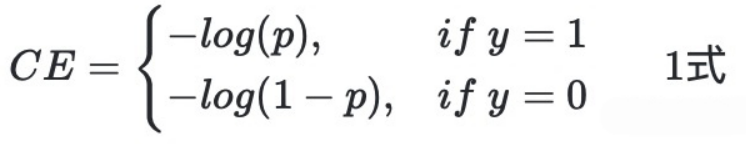

为了解决正负样本不平衡问题，我们通常会在交叉熵损失的前面加上一个参数α， 即:

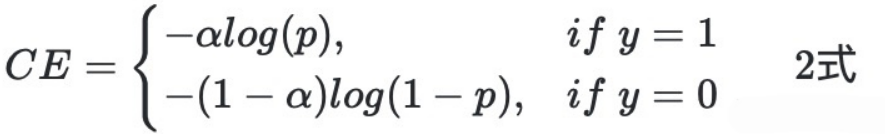

尽管 α 平衡了正负样本，但对难易样本的不平衡没有任何帮助。而实际上，目标检测中大量的候选目标易分样本。这些样本的损失很低，但是由于数量极不平衡，易分样本的数量相对来讲太多，最终主导了总的损失。而本文的作者认为，易分样本（即，置信度高的样本）对模型的提升效果非常小，模型应该主要关注那些难分样本（这个假设是有问题的，是GHM的主要改进对象）

Focal Loss就上场了:一个简单的思想：把高置信度(p)样本（容易分类的样本）的损失再降低一些不就好了吗！

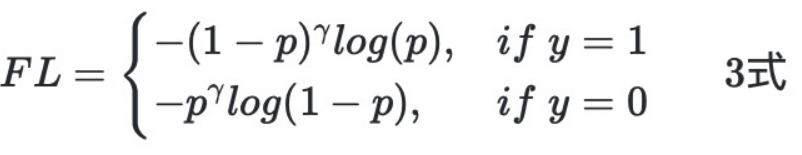

举个例, γ取2时，如果p = 0.968, (1 - 0.968)^2 ≈ 0.001，损失衰减了1000倍

Focal Loss的最终形式结合了上面的公式2解决了正负样本的不平衡，公式3解决了难易样本的不平衡，将公式 2 与 3 结合使用，同时解决正负难易2个问题！

最终的Focal Loss形式如下：

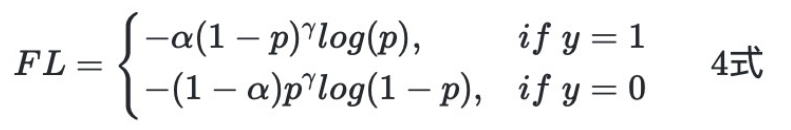

实验表明: γ取2, α取0.25的时候效果更佳。

**Focal loss 代码实现**

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
class FocalLoss(nn.Module):
    def __init__(self, alpha = None, gamma = 0, eps = 1e-7):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.eps = eps
        self.alpha = alpha
        self.ce = torch.nn.CrossEntropyLoss(reduction = 'none')

    def forward(self, input, target):
        logp = self.ce(input, target)
        p = torch.exp(-logp)
        alphas = self.alpha.gather(0, target) #提取每个样本的对应类别权重
        print(alphas)
        loss = (1 - p) ** self.gamma * alphas * logp
        return loss.mean()

loss_func1 = FocalLoss(alpha = torch.Tensor([0.2, 0.3, 0.5]), gamma = 2)
output = torch.FloatTensor(
        [[ 0.6897, -0.4603,  0.9258],
        [-0.6966, -2.1964,  1.0440],
        [-0.8748, -0.7415, -1.2210]]
        )

true_label = torch.LongTensor([0, 2, 1])   # 注意这里的label id必须从0开始 不能说label id是1，2，3 必须是0，1，2
loss = loss_func1(output, true_label)
print(loss) 

# p=F.softmax(output)
# print(p)
# tensor([[0.3872, 0.1226, 0.4903],
#         [0.1444, 0.0322, 0.8233],
#         [0.3509, 0.4009, 0.2482]])

loss1=-0.2*(1-0.3872)**2*np.log(0.3872)+0*-(1-0.1226)**2*np.log(0.1226)+0*-(1-0.4903)**2*np.log(0.4903)
loss2=-0.5*(1-0.8233)**2*np.log(0.8233)
loss3=-0.3*(1-0.4009)**2*np.log(0.4009)
print((loss1+loss2+loss3)/3)

tensor([0.2000, 0.5000, 0.3000])
tensor(0.0576)
0.05757219971980052


#### 3）GHM Loss

Focal Loss存在什么问题呢？

首先，让模型过多关注那些特别难分的样本肯定是存在问题的，样本中有离群点（outliers），可能模型已经收敛了但是这些离群点还是会被判断错误，让模型去关注这样的样本，怎么可能是最好的呢？

其次，α和γ取值全凭实验得出，且α和γ要联合起来一起实验才行(也就是说,α和γ的取值会相互影响)。

Focal Loss是从置信度p的角度入手衰减loss, 而GHM是一定范围内置信度p的样本数量的角度衰减loss。

文章首先定义了一个梯度模长g:

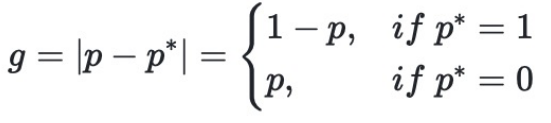

其中，p是模型预测的概率，p*是ground-truth的标签, p\*的取值为0或1。g正比于检测的难易程度，g越大则检测难道越大

看下图梯度模长与样本数量的关系:

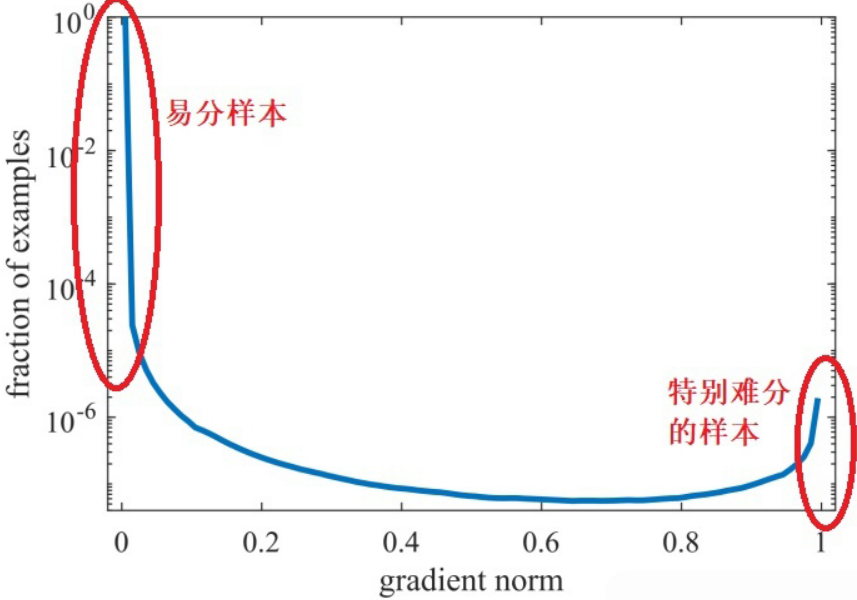

可以看到，梯度模长接近于0的样本数量最多，随着梯度模长的增长，样本数量迅速减少，但是在梯度模长接近于1时，样本数量也挺多。

GHM的想法是，我们确实不应该过多关注易分样本，但是特别难分的样本（outliers，离群点）也不该关注

那怎么同时衰减易分样本和特别难分的样本呢?太简单了，谁的数量多衰减谁呗！那怎么衰减数量多的呢？简单啊，定义一个变量，让这个变量能衡量出一定梯度范围内的样本数量——这不就是物理上密度的概念吗？

于是，作者定义了梯度密度 GD(g) ——本文最重要的公式：

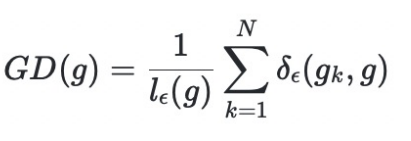

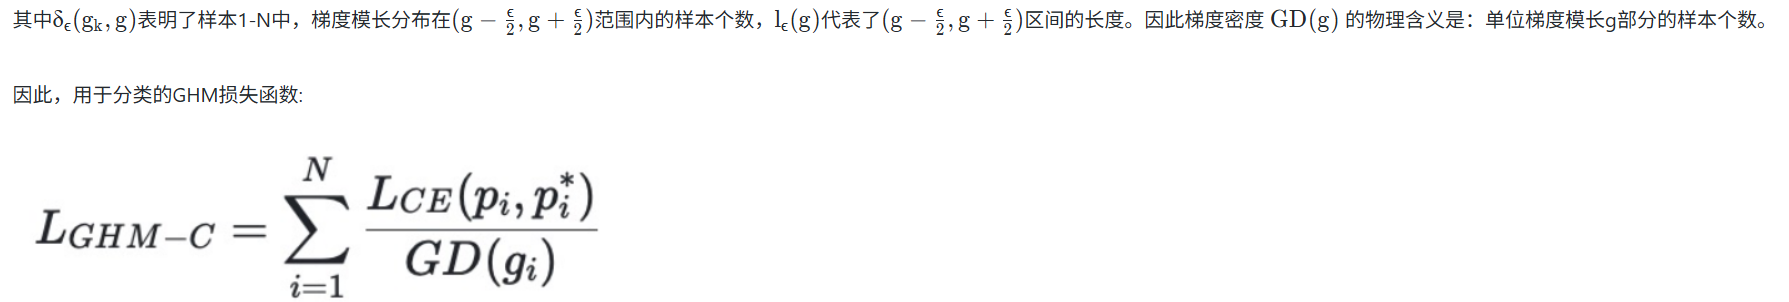

CE/Focal/GHM对比：

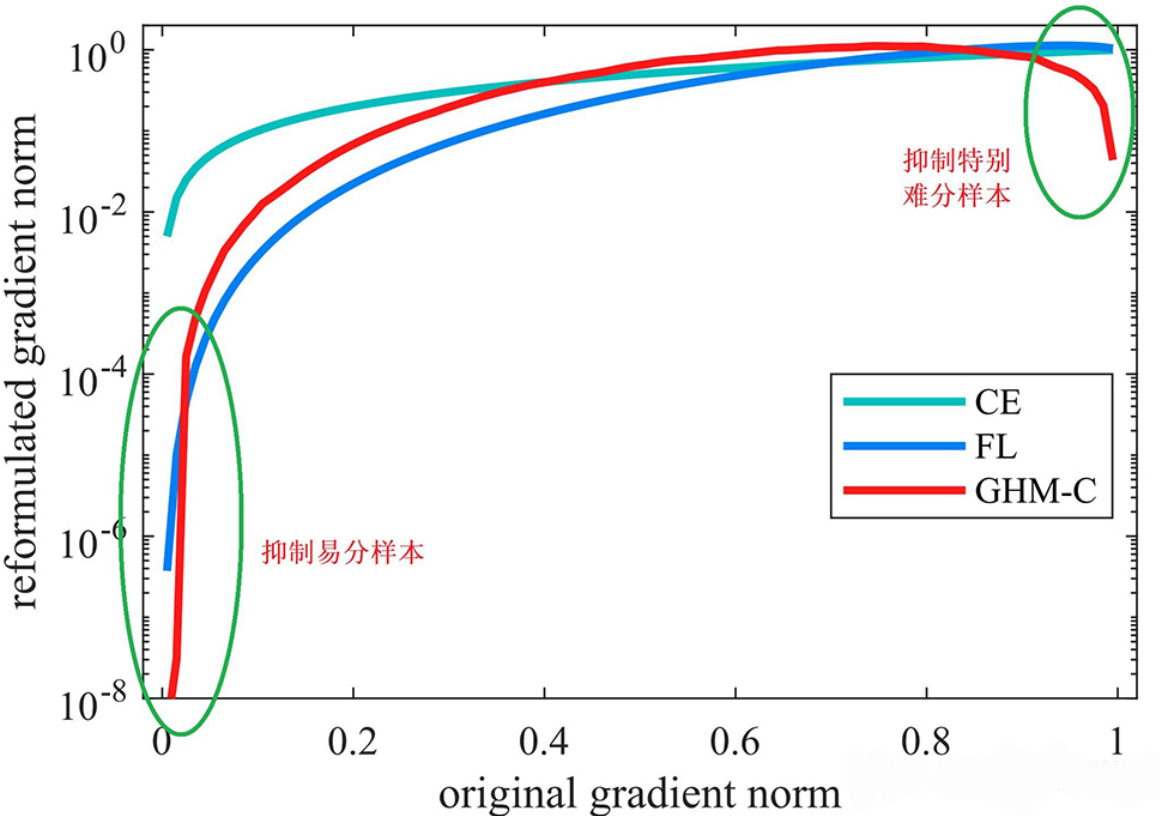

**GHM代码实现**

In [3]:
class GHM_Loss(nn.Module):
    def __init__(self, bins, alpha):
        super(GHM_Loss, self).__init__()
        self._bins = bins
        self._alpha = alpha
        self._last_bin_count = None
    
    def _g2bin(self, g):
        return torch.floor(g * (self._bins - 0.0001)).long()
    
    def _custom_loss(self, x, target, weight): #损失计算的方法
        raise NotImplementedError #子类必须实现
    
    def _custom_loss_grad(self, x, target): #梯度模长的计算方法
        raise NotImplementedError
    
    def forward(self, x, target):
        g = torch.abs(self._custom_loss_grad(x, target)).detach()

        bin_idx = self._g2bin(g)

        bin_count = torch.zeros((self._bins))
        for i in range(self._bins): #统计概率密度
            bin_count[i] = (bin_idx == i).sum().item()
        
        N = (x.size(0) * x.size(1))

        if self._last_bin_count is None:
            self._last_bin_count = bin_count
        else:
            bin_count = self._alpha * self._last_bin_count + (1 - self._alpha) * bin_count
            self._last_bin_count = bin_count
        
        nonempty_bins = (bin_count > 0).sum().item()

        gd = bin_count * nonempty_bins
        gd = torch.clamp(gd, min = 0.0001)
        beta = N / gd

        return self._custom_loss(x, target, beta[bin_idx])

In [4]:
class GHMC_Loss(GHM_Loss):
    # 分类损失
    def __init__(self, bins, alpha):
        super(GHMC_Loss, self).__init__(bins, alpha)

    def _custom_loss(self, x, target, weight):
        return F.binary_cross_entropy_with_logits(x, target, weight)
    
    def _custom_loss_grad(self, x, target):
        return torch.sigmoid(x).detach() - target

class GHMR_Loss(GHM_Loss):
    # 回归损失
    def __init__(self, bins, alpha, mu):
        super(GHMR_Loss, self).__init__(bins, alpha)
        self._mu = mu

    def _custom_loss(self, x, target, weight):
        d = x - target
        mu = self._mu
        loss = torch.sqrt(d * d + mu * mu) - mu
        N = x.size(0) * x.size(1)
        return (loss * weight).sum() / N
    
    def _custom_loss_grad(self, x, target):
        d = x - target
        mu = self._mu
        return d / torch.sqrt(d * d + mu * mu)
    
# 这个损失函数不需要自己进行sigmoid
    output = torch.FloatTensor(
        [
            [0.0550, -0.5005],
            [0.7060, 1.1139]
        ]
    )
    label = torch.FloatTensor(
        [
            [1, 0],
            [0, 1]
        ]
    )
    loss_func = GHMC_Loss(bins=10, alpha=0.75)
    loss = loss_func(output, label)
    print(loss)

tensor(0.6327)
